In [10]:
"""
M11 Transfer Learning Inference - Load and Run Predictions

This notebook loads your trained model and runs inference on new samples.
"""


'\nM11 Transfer Learning Inference - Load and Run Predictions\n\nThis notebook loads your trained model and runs inference on new samples.\n'

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import json


In [12]:
# ============================================================================
# Configuration
# ============================================================================

class InferenceConfig:
    # Paths - UPDATE THESE
    MODEL_PATH = Path("models/best_model.pth")
    NPZ_PATH = Path("/Volumes/ep_ssd/MPL_Data/mmNoTissueFilter/isolated/mm_results_D15F_S6B_2/TRIMMM.npz")
    OUTPUT_DIR = Path("./inference_output")
    
    # Model architecture (must match training)
    ENCODER_NAME = 'resnet34'  # Must match training!
    INPUT_SIZE = (512, 512)    # Must match training!
    
    # Device - auto-detect best available
    if torch.cuda.is_available():
        DEVICE = torch.device('cuda')
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        DEVICE = torch.device('mps')
    else:
        DEVICE = torch.device('cpu')
    
    # Visualization
    SHOW_PLOTS = True

print(f"Device: {InferenceConfig.DEVICE}")


Device: mps


In [13]:
# ============================================================================
# Model Architecture (must match training exactly!)
# ============================================================================

import torchvision.models as models

class UNetWithPretrainedEncoder(nn.Module):
    """U-Net with pretrained encoder - same as training"""
    
    def __init__(self, encoder_name='resnet34', num_classes=2):
        super().__init__()
        
        self.encoder_name = encoder_name
        self.num_classes = num_classes
        
        # Load encoder (no pretrained weights needed for inference)
        if encoder_name == 'resnet18':
            encoder = models.resnet18(weights=None)
            encoder_channels = [64, 64, 128, 256, 512]
        elif encoder_name == 'resnet34':
            encoder = models.resnet34(weights=None)
            encoder_channels = [64, 64, 128, 256, 512]
        elif encoder_name == 'resnet50':
            encoder = models.resnet50(weights=None)
            encoder_channels = [64, 256, 512, 1024, 2048]
        elif encoder_name == 'mobilenet_v2':
            encoder = models.mobilenet_v2(weights=None)
            encoder_channels = [16, 24, 32, 96, 1280]
        else:
            raise ValueError(f"Unsupported encoder: {encoder_name}")
        
        # Extract encoder layers
        if 'resnet' in encoder_name:
            self.encoder0 = nn.Sequential(encoder.conv1, encoder.bn1, encoder.relu)
            self.encoder1 = nn.Sequential(encoder.maxpool, encoder.layer1)
            self.encoder2 = encoder.layer2
            self.encoder3 = encoder.layer3
            self.encoder4 = encoder.layer4
        elif encoder_name == 'mobilenet_v2':
            features = encoder.features
            self.encoder0 = features[0:2]
            self.encoder1 = features[2:4]
            self.encoder2 = features[4:7]
            self.encoder3 = features[7:14]
            self.encoder4 = features[14:]
        
        self.enc_channels = encoder_channels
        
        # Decoder
        self.decoder4 = self._decoder_block(encoder_channels[4] + encoder_channels[3], encoder_channels[3])
        self.decoder3 = self._decoder_block(encoder_channels[3] + encoder_channels[2], encoder_channels[2])
        self.decoder2 = self._decoder_block(encoder_channels[2] + encoder_channels[1], encoder_channels[1])
        self.decoder1 = self._decoder_block(encoder_channels[1] + encoder_channels[0], encoder_channels[0])
        self.decoder0 = self._decoder_block(encoder_channels[0], 64)
        
        self.final_conv = nn.Conv2d(64, num_classes, 1)
    
    def _decoder_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        # Encoder
        enc0 = self.encoder0(x)
        enc1 = self.encoder1(enc0)
        enc2 = self.encoder2(enc1)
        enc3 = self.encoder3(enc2)
        enc4 = self.encoder4(enc3)
        
        # Decoder
        dec4 = F.interpolate(enc4, size=enc3.shape[2:], mode='bilinear', align_corners=True)
        dec4 = torch.cat([dec4, enc3], dim=1)
        dec4 = self.decoder4(dec4)
        
        dec3 = F.interpolate(dec4, size=enc2.shape[2:], mode='bilinear', align_corners=True)
        dec3 = torch.cat([dec3, enc2], dim=1)
        dec3 = self.decoder3(dec3)
        
        dec2 = F.interpolate(dec3, size=enc1.shape[2:], mode='bilinear', align_corners=True)
        dec2 = torch.cat([dec2, enc1], dim=1)
        dec2 = self.decoder2(dec2)
        
        dec1 = F.interpolate(dec2, size=enc0.shape[2:], mode='bilinear', align_corners=True)
        dec1 = torch.cat([dec1, enc0], dim=1)
        dec1 = self.decoder1(dec1)
        
        dec0 = F.interpolate(dec1, size=x.shape[2:], mode='bilinear', align_corners=True)
        dec0 = self.decoder0(dec0)
        
        out = self.final_conv(dec0)
        
        return out

print("✓ Model architecture defined")


✓ Model architecture defined


In [14]:
# ============================================================================
# Data Loading Functions
# ============================================================================

def extract_m11_from_npz(npz_path: Path) -> Optional[np.ndarray]:
    """Extract M11 element from NPZ file."""
    try:
        with np.load(npz_path, allow_pickle=True) as data:
            # Try to get M11
            m11 = None
            if 'nM11s' in data:
                m11 = np.array(data['nM11s'])
                print(f"  Found nM11s: {m11.shape}")
            elif 'M11s' in data:
                m11_raw = np.array(data['M11s'])
                m11_min, m11_max = m11_raw.min(), m11_raw.max()
                if m11_max > m11_min:
                    m11 = (m11_raw - m11_min) / (m11_max - m11_min)
                else:
                    m11 = np.zeros_like(m11_raw, dtype=np.float32)
                print(f"  Found M11s, normalized: {m11.shape}")
            elif 'nM' in data:
                nM = np.array(data['nM'])
                if nM.ndim == 4 and nM.shape[-2:] == (4, 4):
                    m11 = nM[:, :, 0, 0]
                elif nM.ndim == 3 and nM.shape[-1] == 16:
                    m11 = nM[:, :, 0]
                print(f"  Extracted M11 from nM: {m11.shape}")
            
            if m11 is None:
                print("  ERROR: No M11 data found")
                return None
            
            # Try to get ground truth mask (optional)
            mask = None
            for key in ['annotation_mask', 'tissue_mask', 'os_mask']:
                if key in data:
                    mask = np.array(data[key])
                    print(f"  Found mask ({key}): {mask.shape}")
                    break
            
            return m11.astype(np.float32), mask
    
    except Exception as e:
        print(f"ERROR loading {npz_path.name}: {e}")
        return None


def preprocess_m11(m11: np.ndarray, target_size: Tuple[int, int]) -> torch.Tensor:
    """
    Preprocess M11 for model input.
    
    1. Convert to 3-channel (RGB)
    2. Normalize with ImageNet stats
    3. Resize to target size
    4. Convert to tensor
    """
    # Resize if needed
    if m11.shape != target_size:
        m11_torch = torch.from_numpy(m11).float().unsqueeze(0).unsqueeze(0)
        m11_torch = F.interpolate(m11_torch, size=target_size, mode='bilinear', align_corners=True)
        m11 = m11_torch.squeeze().numpy()
    
    # Convert to 3-channel RGB
    m11_rgb = np.stack([m11, m11, m11], axis=0)  # (3, H, W)
    
    # Normalize with ImageNet stats
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    m11_rgb = (m11_rgb - mean) / std
    
    # Convert to tensor
    tensor = torch.from_numpy(m11_rgb).float().unsqueeze(0)  # (1, 3, H, W)
    
    return tensor

print("✓ Data loading functions defined")


✓ Data loading functions defined


In [15]:
# ============================================================================
# Load Model
# ============================================================================

def load_model(model_path: Path, encoder_name: str, device: torch.device):
    """Load trained model from checkpoint."""
    
    print(f"\nLoading model from: {model_path}")
    
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")
    
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location='cpu')
    
    # Get model configuration
    if 'val_loss' in checkpoint:
        print(f"  Training Val Loss: {checkpoint['val_loss']:.4f}")
    if 'val_acc' in checkpoint:
        print(f"  Training Val Acc:  {checkpoint['val_acc']:.4f}")
    if 'epoch' in checkpoint:
        print(f"  Trained Epochs:    {checkpoint['epoch'] + 1}")
    
    # Determine number of classes from state dict
    state_dict = checkpoint['model_state_dict']
    num_classes = state_dict['final_conv.weight'].shape[0]
    print(f"  Number of classes: {num_classes}")
    
    # Create model
    model = UNetWithPretrainedEncoder(
        encoder_name=encoder_name,
        num_classes=num_classes
    )
    
    # Load weights
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    
    print("✓ Model loaded successfully")
    
    return model, num_classes

# Load the model
model, num_classes = load_model(
    InferenceConfig.MODEL_PATH,
    InferenceConfig.ENCODER_NAME,
    InferenceConfig.DEVICE
)



Loading model from: output_m11_transfer_learning/best_model.pth
  Training Val Loss: 0.0768
  Training Val Acc:  0.9701
  Trained Epochs:    21
  Number of classes: 2
✓ Model loaded successfully


In [16]:
# ============================================================================
# Run Inference
# ============================================================================

@torch.no_grad()
def predict(model: nn.Module, 
            npz_path: Path, 
            input_size: Tuple[int, int],
            device: torch.device,
            original_size: Optional[Tuple[int, int]] = None) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """
    Run inference on a single sample with detailed timing.
    
    Returns:
        prediction: (H, W) numpy array with class predictions
        ground_truth: (H, W) numpy array with ground truth (if available)
    """
    
    import time
    timings = {}
    
    print(f"\nRunning inference on: {npz_path.name}")
    print(f"Device: {device.type.upper()}")
    
    # Load data
    t0 = time.time()
    result = extract_m11_from_npz(npz_path)
    if result is None:
        raise ValueError("Failed to load data")
    
    m11, ground_truth = result
    original_shape = m11.shape
    timings['data_loading'] = time.time() - t0
    print(f"  Original size: {original_shape}")
    print(f"  Data loading time: {timings['data_loading']:.4f}s")
    
    # Preprocess
    t0 = time.time()
    input_tensor = preprocess_m11(m11, input_size)
    input_tensor = input_tensor.to(device)
    timings['preprocessing'] = time.time() - t0
    print(f"  Input tensor: {input_tensor.shape}")
    print(f"  Preprocessing time: {timings['preprocessing']:.4f}s")
    
    # Warm-up run (especially important for GPU/MPS)
    if device.type in ['cuda', 'mps']:
        _ = model(input_tensor)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        elif device.type == 'mps':
            torch.mps.synchronize()
    
    # Actual inference with proper synchronization
    t0 = time.time()
    logits = model(input_tensor)  # (1, num_classes, H, W)
    
    # Synchronize to get accurate timing
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps':
        torch.mps.synchronize()
    
    timings['model_inference'] = time.time() - t0
    print(f"  Model inference time: {timings['model_inference']:.4f}s")
    print(f"  Throughput: {1/timings['model_inference']:.2f} FPS")
    
    # Post-processing
    t0 = time.time()
    pred_probs = torch.softmax(logits, dim=1)  # Convert to probabilities
    pred_classes = torch.argmax(logits, dim=1)  # Get class predictions
    
    # Resize back to original size if needed
    if original_size is not None or original_shape != input_size:
        target_size = original_size if original_size else original_shape
        pred_classes = F.interpolate(
            pred_classes.unsqueeze(1).float(), 
            size=target_size, 
            mode='nearest'
        ).squeeze(1).long()
        
        pred_probs = F.interpolate(
            pred_probs,
            size=target_size,
            mode='bilinear',
            align_corners=True
        )
    
    # Convert to numpy
    prediction = pred_classes.cpu().numpy()[0]
    confidence = pred_probs.cpu().numpy()[0]
    
    timings['postprocessing'] = time.time() - t0
    print(f"  Post-processing time: {timings['postprocessing']:.4f}s")
    
    # Total time
    timings['total'] = sum(timings.values())
    print(f"\n  📊 TOTAL TIME: {timings['total']:.4f}s")
    print(f"  Breakdown:")
    for step, t in timings.items():
        if step != 'total':
            percentage = (t / timings['total']) * 100
            print(f"    {step:20s}: {t:.4f}s ({percentage:5.1f}%)")
    
    print(f"\n  Prediction shape: {prediction.shape}")
    print(f"  Unique classes: {np.unique(prediction)}")
    
    # Calculate accuracy if ground truth available
    if ground_truth is not None:
        accuracy = (prediction == ground_truth).mean()
        print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    return prediction, confidence, ground_truth, m11_original, timings


# Run inference
prediction, confidence, ground_truth, m11_original, timings = predict(
    model=model,
    npz_path=InferenceConfig.NPZ_PATH,
    input_size=InferenceConfig.INPUT_SIZE,
    device=InferenceConfig.DEVICE
)



Running inference on: TRIMMM.npz
Device: MPS
  Found nM11s: (1078, 1278)
  Found mask (tissue_mask): (1078, 1278)
  Original size: (1078, 1278)
  Data loading time: 0.0260s
  Input tensor: torch.Size([1, 3, 512, 512])
  Preprocessing time: 0.0030s
  Model inference time: 0.0155s
  Throughput: 64.67 FPS
  Post-processing time: 0.4144s

  📊 TOTAL TIME: 0.4588s
  Breakdown:
    data_loading        : 0.0260s (  5.7%)
    preprocessing       : 0.0030s (  0.7%)
    model_inference     : 0.0155s (  3.4%)
    postprocessing      : 0.4144s ( 90.3%)

  Prediction shape: (1078, 1278)
  Unique classes: [0 1]
  Accuracy: 0.9904 (99.04%)


/var/folders/wz/f5xv3w617c11h_4f0jx1glbr0000gn/T/ipykernel_10700/829990891.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


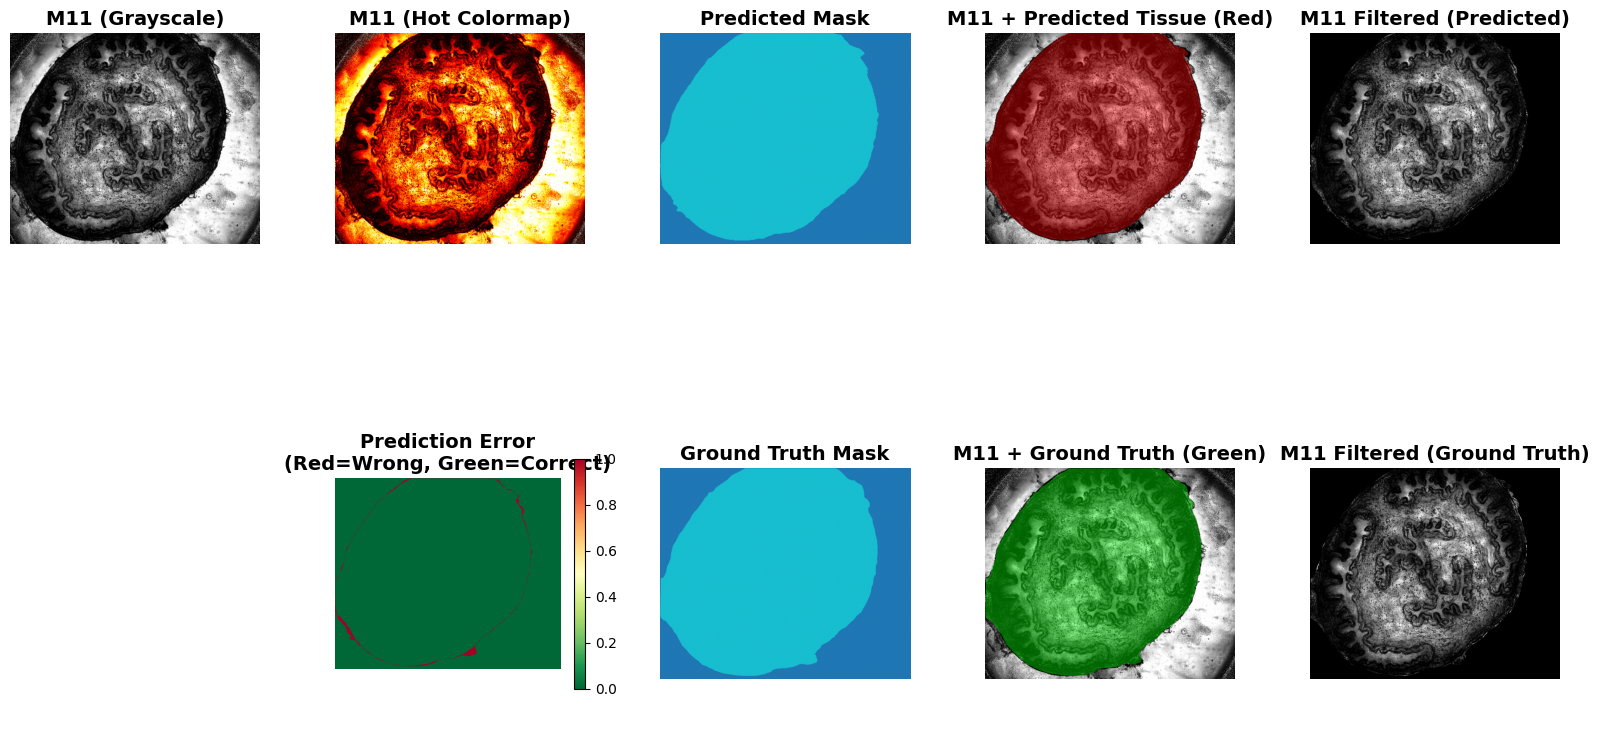


SEGMENTATION STATISTICS
Predicted Background     :   458972 pixels (33.31%)
Predicted Tissue         :   918712 pixels (66.69%)

GROUND TRUTH STATISTICS
GT Background     :   458498 pixels (33.28%)
GT Tissue         :   919186 pixels (66.72%)

INTERSECTION OVER UNION (IoU)
Background     : 0.9715 (97.15%)
Tissue         : 0.9857 (98.57%)

Overall Accuracy: 0.9904 (99.04%)
Dice Tissue         : 0.9928 (99.28%)


In [17]:
# ============================================================================
# Visualize Results
# ============================================================================

def visualize_results(m11: np.ndarray, 
                     prediction: np.ndarray, 
                     confidence: np.ndarray,
                     ground_truth: Optional[np.ndarray] = None,
                     class_names: Optional[list] = None):
    """Visualize inference results with grayscale M11 and masked overlays."""
    
    if class_names is None:
        class_names = [f"Class {i}" for i in range(confidence.shape[0])]
    
    # Create figure with 2 rows
    if ground_truth is not None:
        fig = plt.figure(figsize=(20, 10))
        gs = fig.add_gridspec(2, 5, hspace=0.3, wspace=0.3)
    else:
        fig = plt.figure(figsize=(20, 6))
        gs = fig.add_gridspec(1, 5, hspace=0.3, wspace=0.3)
    
    # Row 1: Original visualizations
    # 1. M11 Grayscale (Gray intensity)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(m11, cmap='gray', vmin=0, vmax=1)
    ax1.set_title('M11 (Grayscale)', fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # 2. M11 Hot colormap
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(m11, cmap='hot')
    ax2.set_title('M11 (Hot Colormap)', fontsize=14, fontweight='bold')
    ax2.axis('off')
    
    # 3. Prediction mask
    ax3 = fig.add_subplot(gs[0, 2])
    im3 = ax3.imshow(prediction, cmap='tab10', vmin=0, vmax=len(class_names)-1)
    ax3.set_title('Predicted Mask', fontsize=14, fontweight='bold')
    ax3.axis('off')
    
    # 4. M11 with Predicted mask overlay
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.imshow(m11, cmap='gray', vmin=0, vmax=1)
    # Create colored overlay where prediction == 1 (tissue)
    overlay_pred = np.zeros((*prediction.shape, 4))
    tissue_mask_pred = prediction > 0
    overlay_pred[tissue_mask_pred] = [1, 0, 0, 0.4]  # Red with 40% transparency
    ax4.imshow(overlay_pred)
    ax4.set_title('M11 + Predicted Tissue (Red)', fontsize=14, fontweight='bold')
    ax4.axis('off')
    
    # 5. M11 filtered by predicted mask (show only tissue regions)
    ax5 = fig.add_subplot(gs[0, 4])
    m11_filtered_pred = m11.copy()
    m11_filtered_pred[~tissue_mask_pred] = 0  # Set non-tissue to black
    ax5.imshow(m11_filtered_pred, cmap='gray', vmin=0, vmax=1)
    ax5.set_title('M11 Filtered (Predicted)', fontsize=14, fontweight='bold')
    ax5.axis('off')
    
    # Row 2: Ground truth comparisons (if available)
    if ground_truth is not None:
        # 1. Empty (for symmetry)
        ax6 = fig.add_subplot(gs[1, 0])
        ax6.axis('off')
        
        # 2. Difference map
        ax7 = fig.add_subplot(gs[1, 1])
        difference = (prediction != ground_truth).astype(np.float32)
        im7 = ax7.imshow(difference, cmap='RdYlGn_r', vmin=0, vmax=1)
        ax7.set_title('Prediction Error\n(Red=Wrong, Green=Correct)', fontsize=14, fontweight='bold')
        ax7.axis('off')
        plt.colorbar(im7, ax=ax7, fraction=0.046)
        
        # 3. Ground truth mask
        ax8 = fig.add_subplot(gs[1, 2])
        im8 = ax8.imshow(ground_truth, cmap='tab10', vmin=0, vmax=len(class_names)-1)
        ax8.set_title('Ground Truth Mask', fontsize=14, fontweight='bold')
        ax8.axis('off')
        
        # 4. M11 with Ground truth overlay
        ax9 = fig.add_subplot(gs[1, 3])
        ax9.imshow(m11, cmap='gray', vmin=0, vmax=1)
        overlay_gt = np.zeros((*ground_truth.shape, 4))
        tissue_mask_gt = ground_truth > 0
        overlay_gt[tissue_mask_gt] = [0, 1, 0, 0.4]  # Green with 40% transparency
        ax9.imshow(overlay_gt)
        ax9.set_title('M11 + Ground Truth (Green)', fontsize=14, fontweight='bold')
        ax9.axis('off')
        
        # 5. M11 filtered by ground truth mask
        ax10 = fig.add_subplot(gs[1, 4])
        m11_filtered_gt = m11.copy()
        m11_filtered_gt[~tissue_mask_gt] = 0
        ax10.imshow(m11_filtered_gt, cmap='gray', vmin=0, vmax=1)
        ax10.set_title('M11 Filtered (Ground Truth)', fontsize=14, fontweight='bold')
        ax10.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "="*60)
    print("SEGMENTATION STATISTICS")
    print("="*60)
    
    for i, class_name in enumerate(class_names):
        pixels = (prediction == i).sum()
        percentage = pixels / prediction.size * 100
        print(f"Predicted {class_name:15s}: {pixels:8d} pixels ({percentage:5.2f}%)")
    
    if ground_truth is not None:
        print("\n" + "="*60)
        print("GROUND TRUTH STATISTICS")
        print("="*60)
        for i, class_name in enumerate(class_names):
            pixels = (ground_truth == i).sum()
            percentage = pixels / ground_truth.size * 100
            print(f"GT {class_name:15s}: {pixels:8d} pixels ({percentage:5.2f}%)")
        
        # Calculate IoU for each class
        print("\n" + "="*60)
        print("INTERSECTION OVER UNION (IoU)")
        print("="*60)
        for i, class_name in enumerate(class_names):
            pred_mask = (prediction == i)
            gt_mask = (ground_truth == i)
            intersection = (pred_mask & gt_mask).sum()
            union = (pred_mask | gt_mask).sum()
            iou = intersection / union if union > 0 else 0
            print(f"{class_name:15s}: {iou:.4f} ({iou*100:.2f}%)")
        
        # Overall accuracy
        accuracy = (prediction == ground_truth).mean()
        print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
        
        # Dice coefficient (F1 score for segmentation)
        for i, class_name in enumerate(class_names):
            if i == 0:  # Skip background
                continue
            pred_mask = (prediction == i)
            gt_mask = (ground_truth == i)
            intersection = (pred_mask & gt_mask).sum()
            dice = (2 * intersection) / (pred_mask.sum() + gt_mask.sum()) if (pred_mask.sum() + gt_mask.sum()) > 0 else 0
            print(f"Dice {class_name:15s}: {dice:.4f} ({dice*100:.2f}%)")


# Visualize
if InferenceConfig.SHOW_PLOTS:
    visualize_results(
        m11=m11_original,
        prediction=prediction,
        confidence=confidence,
        ground_truth=ground_truth,
        class_names=['Background', 'Tissue']  # Adjust based on your classes
    )


In [23]:
# ============================================================================
# Runtime Performance Analysis (Simplified - Milliseconds)
# ============================================================================

def print_runtime_analysis(timings: dict, device_type: str, prediction_shape: tuple):
    """Print simplified runtime analysis in milliseconds."""
    
    print("\n" + "="*60)
    print(f"RUNTIME PERFORMANCE ({device_type.upper()})")
    print("="*60)
    
    # Key metrics in milliseconds
    print(f"Total time:       {timings['total']*1000:.2f} ms")
    print(f"Model inference:  {timings['model_inference']*1000:.2f} ms")
    print(f"Throughput:       {1/timings['model_inference']:.2f} FPS")
    
    # Time breakdown
    print(f"\nBreakdown:")
    for key, val in timings.items():
        if key != 'total':
            pct = (val / timings['total']) * 100
            print(f"  {key:20s}: {val*1000:7.2f} ms ({pct:5.1f}%)")
    
    # Dataset estimates
    print(f"\nEstimated processing time:")
    print(f"  100 images:  {(timings['total'] * 100) / 60:.1f} minutes")
    print(f"  500 images:  {(timings['total'] * 500) / 60:.1f} minutes")
    print(f"  1000 images: {(timings['total'] * 1000) / 60:.1f} minutes")
    
    print("="*60)


# Usage:
print_runtime_analysis(timings, InferenceConfig.DEVICE.type, prediction.shape)


RUNTIME PERFORMANCE (MPS)
Total time:       458.83 ms
Model inference:  15.46 ms
Throughput:       64.67 FPS

Breakdown:
  data_loading        :   25.96 ms (  5.7%)
  preprocessing       :    3.04 ms (  0.7%)
  model_inference     :   15.46 ms (  3.4%)
  postprocessing      :  414.37 ms ( 90.3%)

Estimated processing time:
  100 images:  0.8 minutes
  500 images:  3.8 minutes
  1000 images: 7.6 minutes


In [19]:
# ============================================================================
# Save Results
# ============================================================================

def save_results(output_dir: Path,
                npz_path: Path,
                prediction: np.ndarray,
                confidence: np.ndarray,
                ground_truth: Optional[np.ndarray] = None):
    """Save inference results to disk."""
    
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Save prediction
    np.save(output_dir / 'prediction.npy', prediction)
    print(f"✓ Saved prediction to: {output_dir / 'prediction.npy'}")
    
    # Save confidence
    np.save(output_dir / 'confidence.npy', confidence)
    print(f"✓ Saved confidence to: {output_dir / 'confidence.npy'}")
    
    # Save ground truth if available
    if ground_truth is not None:
        np.save(output_dir / 'ground_truth.npy', ground_truth)
        print(f"✓ Saved ground truth to: {output_dir / 'ground_truth.npy'}")
    
    # Save metadata
    metadata = {
        'npz_path': str(npz_path),
        'prediction_shape': prediction.shape,
        'num_classes': int(confidence.shape[0]),
        'unique_classes': [int(x) for x in np.unique(prediction)],
    }
    
    if ground_truth is not None:
        accuracy = float((prediction == ground_truth).mean())
        metadata['accuracy'] = accuracy
    
    with open(output_dir / 'inference_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"✓ Saved metadata to: {output_dir / 'inference_metadata.json'}")


# Save results
save_results(
    output_dir=InferenceConfig.OUTPUT_DIR,
    npz_path=InferenceConfig.NPZ_PATH,
    prediction=prediction,
    confidence=confidence,
    ground_truth=ground_truth
)


✓ Saved prediction to: inference_output/prediction.npy
✓ Saved confidence to: inference_output/confidence.npy
✓ Saved ground truth to: inference_output/ground_truth.npy
✓ Saved metadata to: inference_output/inference_metadata.json


In [20]:
# ============================================================================
# Batch Inference (Optional)
# ============================================================================

def batch_inference(model: nn.Module,
                   npz_files: list,
                   input_size: Tuple[int, int],
                   device: torch.device,
                   output_dir: Path):
    """Run inference on multiple files with timing."""
    
    output_dir.mkdir(parents=True, exist_ok=True)
    
    results = []
    all_timings = []
    
    for npz_path in npz_files:
        print(f"\n{'='*60}")
        print(f"Processing: {npz_path.name}")
        print(f"{'='*60}")
        
        try:
            pred, conf, gt, m11, timings = predict(model, npz_path, input_size, device)
            
            # Save individual results
            sample_dir = output_dir / npz_path.stem
            save_results(sample_dir, npz_path, pred, conf, gt)
            
            # Collect summary
            result = {
                'file': npz_path.name,
                'shape': pred.shape,
                'unique_classes': [int(x) for x in np.unique(pred)],
                'inference_time': timings['model_inference'],
                'total_time': timings['total']
            }
            
            if gt is not None:
                result['accuracy'] = float((pred == gt).mean())
            
            results.append(result)
            all_timings.append(timings)
            
        except Exception as e:
            print(f"ERROR processing {npz_path.name}: {e}")
            results.append({'file': npz_path.name, 'error': str(e)})
    
    # Calculate average timings
    if all_timings:
        avg_timings = {}
        for key in all_timings[0].keys():
            avg_timings[f'avg_{key}'] = np.mean([t[key] for t in all_timings])
            avg_timings[f'std_{key}'] = np.std([t[key] for t in all_timings])
        
        print("\n" + "="*60)
        print(f"BATCH PROCESSING SUMMARY ({len(all_timings)} samples)")
        print("="*60)
        print(f"Average inference time: {avg_timings['avg_model_inference']:.4f}s ± {avg_timings['std_model_inference']:.4f}s")
        print(f"Average total time:     {avg_timings['avg_total']:.4f}s ± {avg_timings['std_total']:.4f}s")
        print(f"Total processing time:  {sum(t['total'] for t in all_timings):.2f}s")
        print(f"Average throughput:     {1/avg_timings['avg_model_inference']:.2f} FPS")
        
        results.append({'summary': avg_timings})
    
    # Save summary
    with open(output_dir / 'batch_summary.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"\n✓ Batch inference complete! Results saved to: {output_dir}")
    
    return results


# Example: Run batch inference on a directory
# Uncomment to use:
"""
test_dir = Path("/path/to/test/samples")
npz_files = list(test_dir.rglob("*.npz"))
print(f"Found {len(npz_files)} NPZ files")

batch_results = batch_inference(
    model=model,
    npz_files=npz_files,
    input_size=InferenceConfig.INPUT_SIZE,
    device=InferenceConfig.DEVICE,
    output_dir=Path("./batch_inference_output")
)
"""


'\ntest_dir = Path("/path/to/test/samples")\nnpz_files = list(test_dir.rglob("*.npz"))\nprint(f"Found {len(npz_files)} NPZ files")\n\nbatch_results = batch_inference(\n    model=model,\n    npz_files=npz_files,\n    input_size=InferenceConfig.INPUT_SIZE,\n    device=InferenceConfig.DEVICE,\n    output_dir=Path("./batch_inference_output")\n)\n'

In [ ]:
print("\n" + "="*60)
print("INFERENCE COMPLETE!")
print("="*60)
print(f"Results saved to: {InferenceConfig.OUTPUT_DIR}")
